In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
def quadruple(y):
    ''' Quadruple y '''
    return 4*y

In [3]:
quadruple?

Signature: quadruple(y)
Docstring: Quadruple y 
File:      c:\users\ln015\appdata\local\temp\ipykernel_28992\2015895397.py
Type:      function

In [5]:
quadruple(42)

168

In [6]:
quadruple(3.14)

12.56

In [7]:
quadruple('hi mom')

'hi momhi momhi momhi mom'

In [8]:
quadruple(make_array(4, 5, 6))

array([16, 20, 24])

In [9]:
y

NameError: name 'y' is not defined

In [16]:
def percents(counts):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, 2)

In [17]:
percents(make_array(20, 25, 30))

array([ 26.67,  33.33,  40.  ])

In [19]:
def percents(counts, decimal_places):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, decimal_places)

In [20]:
percents(make_array(20, 25, 30), 3)

array([ 26.667,  33.333,  40.   ])

In [21]:
percents(make_array(20, 25, 30))

TypeError: percents() missing 1 required positional argument: 'decimal_places'

In [22]:
def percents(counts, decimal_places=2):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, decimal_places)

In [23]:
percents(make_array(20, 25, 30))

array([ 26.67,  33.33,  40.  ])

In [24]:
percents(make_array(20, 25, 30), 3)

array([ 26.667,  33.333,  40.   ])

# Applying functions to Tables

In [25]:
places = Table().with_columns(
    'Place', make_array('Fresno', 'Death Valley', 'Shaver Lake'),
    'Elevation', make_array(308, -282, 5627)
)
places

Place,Elevation
Fresno,308
Death Valley,-282
Shaver Lake,5627


In [26]:
def cut_off_at_0(val):
    return max(0, val)

In [28]:
cut_off_at_0(-5), cut_off_at_0(0), cut_off_at_0(42)

(0, 0, 42)

In [29]:
places.apply(cut_off_at_0, 'Elevation')

array([ 308,    0, 5627])

In [30]:
places.with_column('Cut off elevation', places.apply(cut_off_at_0, 'Elevation'))

Place,Elevation,Cut off elevation
Fresno,308,308
Death Valley,-282,0
Shaver Lake,5627,5627


In [31]:
cut_off_at_0

<function __main__.cut_off_at_0(val)>

In [32]:
cut = cut_off_at_0

In [33]:
cut(-5)

0

In [34]:
cut_off_at_0(42)

42

In [37]:
def calculate_total(price, tax_rate):
    result = price + price * (tax_rate / 100)
    return round(result, 2)

In [38]:
calculate_total(5.99, 8.35)

6.49

In [39]:
calculate_total(7.99, 8.75)

8.69

# Prediction

In [41]:
family_heights = Table.read_table('data/family_heights.csv').drop(3)
family_heights

family,father,mother,children,childNum,sex,childHeight
1,78.5,67,4,1,male,73.2
1,78.5,67,4,2,female,69.2
1,78.5,67,4,3,female,69
1,78.5,67,4,4,female,69
2,75.5,66.5,4,1,male,73.5
2,75.5,66.5,4,2,male,72.5
2,75.5,66.5,4,3,female,65.5
2,75.5,66.5,4,4,female,65.5
3,75,64,2,1,male,71
3,75,64,2,2,female,68


In [42]:
parent_averages = (family_heights.column('father') + family_heights.column('mother')) / 2
heights = Table().with_columns(
    'Parent Average', parent_averages,
    'Child', family_heights.column('childHeight')
)
heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


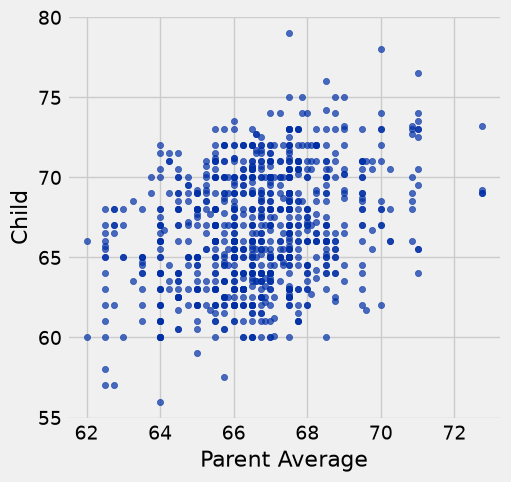

In [43]:
heights.scatter('Parent Average')

In [45]:
close_to_66 = heights.where('Parent Average', are.between(65.5, 66.5))
close_to_66

Parent Average,Child
66,62
66.25,72
66.25,70
66.25,69.5
66.25,69.5
66.25,68
66.25,65
66.25,64
66.25,63
66.25,72


In [46]:
min(close_to_66.column('Child')), max(close_to_66.column('Child'))

(57.5, 73.5)

In [47]:
np.average(close_to_66.column('Child'))

66.086407766990291

In [48]:
def predict_child(p_avg):
    close_points = heights.where('Parent Average', are.between(p_avg - 0.5, p_avg + 0.5))
    return np.average(close_points.column('Child'))

In [49]:
predict_child(66)

66.086407766990291

In [50]:
predict_child(70)

68.561904761904756

In [53]:
heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'Parent Average')
)
heights_with_predictions

Parent Average,Child,Prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158
71,72.5,70.4158
71,65.5,70.4158
71,65.5,70.4158
69.5,71,68.5025
69.5,68,68.5025


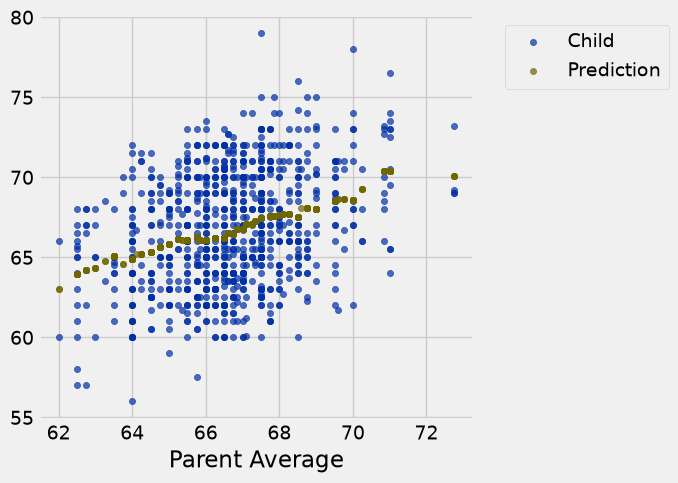

In [54]:
heights_with_predictions.scatter('Parent Average')

# Grouping

In [55]:
cones = Table.read_table('data/cones.csv')
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
vanilla,white,3.5
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [56]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2
vanilla,1


In [57]:
cones.group('Flavor', np.average)

Flavor,Color average,Price average
bubblegum,,4.75
chocolate,,5.08333
strawberry,,4.4
vanilla,,3.5


In [58]:
cones.group('Flavor', list)

Flavor,Color list,Price list
bubblegum,['pink'],[4.75]
chocolate,"['light brown', 'dark brown', 'dark brown']","[4.75, 5.25, 5.25]"
strawberry,"['pink', 'pink']","[3.5499999999999998, 5.25]"
vanilla,['white'],[3.5]


In [59]:
cones.group('Flavor', sum)

Flavor,Color sum,Price sum
bubblegum,,4.75
chocolate,,15.25
strawberry,,8.8
vanilla,,3.5


In [61]:
cones.drop('Color').group('Flavor', max)

Flavor,Price max
bubblegum,4.75
chocolate,5.25
strawberry,5.25
vanilla,3.5
